# Clean nucleus migration candidate search and GIF builder

This notebook does four things:

1. Loads the metadata CSV and the real aligned `path_background` / `path_dapi` crops.
2. Builds 20 frame templates for entry → full → exit.
3. Finds candidate nuclei for each frame and reranks them with a stronger migration-position penalty.
4. Builds:
   - one stabilized automatic GIF
   - ten randomized GIFs sampled from the top candidate pool

## Expected inputs

- `combined_clustered_data 1462.csv`
- the images referenced by `path_background` and `path_dapi`

## Notes

- This notebook uses the **real background/DAPI alignment**, not a synthetic reprojection.
- Frame jitter is reduced with **fixed-size centroid crops**.
- You can control animation speed with:
  - `GIF_FRAME_DURATION`
  - `GIF_HOLD_MIDDLE_N`
  - `GIF_HOLD_LAST_N`

In [1]:

# =========================
# 1. Imports and settings
# =========================
import re
import ast
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from PIL import Image
from tifffile import imread

plt.rcParams["figure.dpi"] = 120

# ---------- USER SETTINGS ----------
CSV_PATH = Path("C:\\Users\\20212358\\OneDrive - TU Eindhoven\\pseudotime_GitHUB\\pseudotime\\datasets\\Figure_12_GIF\\combined_clustered_data_1462_k5.csv")
OUT_DIR = Path("Figure12__090426")

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Visual + GIF settings
GIF_FRAME_SIZE = (980, 360)   # width, height
GIF_FRAME_DURATION = 0.8      # seconds per frame
GIF_HOLD_MIDDLE_N = 2
GIF_HOLD_LAST_N = 6

OVERLAY_CROP_HW = (220, 220)
DAPI_CROP_HW = (180, 180)

# Candidate search
PROFILE_RESAMPLE_N = 100
TOP_K_PER_FRAME = 15
MIGRATION_WEIGHT = 0.55
DAPI_MASK_REL_THRESHOLD = 0.15

# Sequence selection
SEQUENCE_MODE = "greedy_smooth"   # "greedy" or "greedy_smooth"

print("Outputs ->", OUT_DIR.resolve())

Outputs -> C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\Figure12__090426


## 2. Core helper functions

In [2]:

# =========================
# 2. Parsing / loading helpers
# =========================
def parse_vec(x, dtype=float):
    if isinstance(x, np.ndarray):
        return x.astype(dtype)
    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)
    if pd.isna(x):
        return np.array([], dtype=dtype)

    s = str(x).replace("[", "").replace("]", "").strip()
    if not s:
        return np.array([], dtype=dtype)

    parts = [p for p in s.replace(",", " ").split() if p]
    return np.asarray(parts, dtype=dtype)


def build_unique_key(row):
    img_num = row.get("dapi_ImageNumber", np.nan)
    obj_num = row.get("ObjectNumber", np.nan)

    if pd.notna(img_num) and pd.notna(obj_num):
        return f"img{int(img_num):05d}_obj{int(obj_num):05d}"

    path_dapi = str(row.get("path_dapi", "missing"))
    stem = Path(path_dapi).stem
    if pd.notna(obj_num):
        return f"{stem}_obj{int(obj_num):05d}"
    return stem


def resolve_path(path_str):
    p = Path(str(path_str))
    if p.exists():
        return p

    # fallback to basename in current working directory
    p2 = Path(p.name)
    if p2.exists():
        return p2

    return p


def read_image(path_str):
    p = resolve_path(path_str)
    arr = imread(str(p))
    arr = np.asarray(arr)
    return arr


def to_2d(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)
    if arr.ndim == 3:
        return arr[..., 0]
    return arr


def normalize_percentile(arr, p_low=1, p_high=99):
    x = np.asarray(arr).astype(np.float32)
    lo = np.percentile(x, p_low)
    hi = np.percentile(x, p_high)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)


def scale_dapi_fixed(dapi_2d, out_hw=(180, 180)):
    pil = Image.fromarray((normalize_percentile(dapi_2d) * 255).astype(np.uint8))
    pil = pil.resize((out_hw[1], out_hw[0]), resample=Image.BILINEAR)
    return np.asarray(pil).astype(np.float32) / 255.0


def normalize_background(bg_2d):
    return normalize_percentile(bg_2d, 1, 99)


def make_overlay_fixed_dapi(background_2d, dapi_fixed):
    '''
    background and dapi_fixed should already be in the same output size
    Returns an RGB image:
      background -> gray
      dapi -> blue
    '''
    bg = normalize_background(background_2d)
    if bg.shape != dapi_fixed.shape:
        pil = Image.fromarray((bg * 255).astype(np.uint8))
        pil = pil.resize((dapi_fixed.shape[1], dapi_fixed.shape[0]), resample=Image.BILINEAR)
        bg = np.asarray(pil).astype(np.float32) / 255.0

    rgb = np.dstack([bg, bg, bg])
    rgb[..., 2] = np.maximum(rgb[..., 2], dapi_fixed)  # blue channel
    return np.clip(rgb, 0, 1)


def make_binary_mask_from_dapi(dapi_img, rel_thr=DAPI_MASK_REL_THRESHOLD):
    arr = np.asarray(dapi_img).astype(np.float32)
    if arr.size == 0:
        return np.zeros_like(arr, dtype=bool)

    vmax = float(arr.max())
    if vmax <= 0:
        return np.zeros_like(arr, dtype=bool)

    thr = vmax * rel_thr
    return arr > thr


def mask_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    return float(ys.mean()), float(xs.mean())


def fixed_center_crop(arr, center_y, center_x, crop_h, crop_w, fill_value=0):
    arr = np.asarray(arr)
    H, W = arr.shape[:2]

    y0 = int(round(center_y - crop_h / 2))
    x0 = int(round(center_x - crop_w / 2))
    y1 = y0 + crop_h
    x1 = x0 + crop_w

    src_y0 = max(0, y0)
    src_x0 = max(0, x0)
    src_y1 = min(H, y1)
    src_x1 = min(W, x1)

    dst_y0 = src_y0 - y0
    dst_x0 = src_x0 - x0
    dst_y1 = dst_y0 + (src_y1 - src_y0)
    dst_x1 = dst_x0 + (src_x1 - src_x0)

    if arr.ndim == 2:
        out = np.full((crop_h, crop_w), fill_value, dtype=arr.dtype)
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    else:
        if np.isscalar(fill_value):
            fill = [fill_value] * arr.shape[2]
        else:
            fill = fill_value

        out = np.zeros((crop_h, crop_w, arr.shape[2]), dtype=arr.dtype)
        for c in range(arr.shape[2]):
            out[..., c] = fill[c]
        out[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]

    return out


def pad_to_canvas(img, out_w, out_h, bg_value=255):
    arr = np.asarray(img)

    if arr.ndim == 2:
        canvas = np.full((out_h, out_w), bg_value, dtype=arr.dtype)
    else:
        canvas = np.full((out_h, out_w, arr.shape[2]), bg_value, dtype=arr.dtype)

    h, w = arr.shape[:2]
    if h == 0 or w == 0:
        return canvas

    scale = min(out_w / w, out_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    pil = Image.fromarray((arr * 255).astype(np.uint8) if arr.dtype != np.uint8 else arr)
    pil = pil.resize((new_w, new_h), resample=Image.BILINEAR)
    arr2 = np.asarray(pil)

    y0 = (out_h - new_h) // 2
    x0 = (out_w - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = arr2
    return canvas

In [3]:

# =========================
# 3. Pseudotime profile helpers
# =========================
def centered_width_profile(pt_bins, pt_widths, center_bin):
    '''
    Rotate widths so center_bin is the first position.
    '''
    pt_bins = np.asarray(pt_bins, dtype=int)
    pt_widths = np.asarray(pt_widths, dtype=float)

    if len(pt_bins) == 0 or len(pt_widths) == 0 or len(pt_bins) != len(pt_widths):
        return np.array([], dtype=float), np.array([], dtype=int)

    matches = np.where(pt_bins == int(center_bin))[0]
    if len(matches) == 0:
        start_idx = 0
    else:
        start_idx = int(matches[0])

    bins_rot = np.roll(pt_bins, -start_idx)
    widths_rot = np.roll(pt_widths, -start_idx)
    return widths_rot, bins_rot


def normalize_profile(v):
    v = np.asarray(v, dtype=float)
    if len(v) == 0:
        return v
    s = v.sum()
    if s <= 0:
        return np.zeros_like(v, dtype=float)
    return v / s


def resample_profile(v, n=100):
    v = np.asarray(v, dtype=float)
    if len(v) == 0:
        return np.zeros(n, dtype=float)
    if len(v) == 1:
        return np.repeat(v[0], n).astype(float)

    x_old = np.linspace(0, 1, len(v))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, v)


def profile_features(profile):
    p = np.asarray(profile, dtype=float)
    if len(p) == 0 or np.sum(p) <= 0:
        return {
            "mean_pos": np.nan,
            "spread": np.nan,
            "left_mass": np.nan,
            "right_mass": np.nan,
            "center_mass": np.nan,
            "coverage": np.nan,
        }

    x = np.linspace(0, 1, len(p))
    w = p / p.sum()

    mean_pos = float((x * w).sum())
    spread = float(np.sqrt(((x - mean_pos) ** 2 * w).sum()))

    left_mass = float(w[x <= 0.33].sum())
    center_mass = float(w[(x > 0.33) & (x < 0.67)].sum())
    right_mass = float(w[x >= 0.67].sum())
    coverage = float((p > 0).mean())

    return {
        "mean_pos": mean_pos,
        "spread": spread,
        "left_mass": left_mass,
        "right_mass": right_mass,
        "center_mass": center_mass,
        "coverage": coverage,
    }

In [4]:

# =========================
# 4. Frame templates and migration-strength model
# =========================
def make_20_frame_templates(n=100):
    '''
    20 frames:
    10 entry-like
    1 full hold
    9 exit-like
    '''
    templates = []

    # entry: [0, 0.1] ... [0, 1.0]
    for i in range(1, 11):
        frac = i / 10
        t = np.zeros(n, dtype=float)
        t[:max(1, int(round(frac * n)))] = 1.0
        templates.append({
            "frame_idx": i,
            "frame_name": f"f{i:02d}_entry_{int(frac*100):02d}",
            "template": t
        })

    # full hold
    t = np.ones(n, dtype=float)
    templates.append({
        "frame_idx": 11,
        "frame_name": "f11_full_hold",
        "template": t.copy()
    })

    # exit: [0.1,1.0] ... [0.9,1.0]
    for j, frac in enumerate(np.arange(0.1, 1.0, 0.1), start=12):
        t = np.ones(n, dtype=float)
        t[:int(round(frac * n))] = 0.0
        remain = int(round((1.0 - frac) * 100))
        templates.append({
            "frame_idx": j,
            "frame_name": f"f{j:02d}_exit_{remain:02d}",
            "template": t
        })

    return templates


FRAME_TEMPLATES = make_20_frame_templates(n=PROFILE_RESAMPLE_N)
FRAME_ORDER = [spec["frame_name"] for spec in FRAME_TEMPLATES]
FRAME_TEMPLATE_MAP = {spec["frame_name"]: spec for spec in FRAME_TEMPLATES}

def expected_position_for_frame(frame_name):
    idx = int(str(frame_name).split("_")[0][1:])

    if 1 <= idx <= 10:
        frac = idx / 10.0
        target_mean = 0.08 + 0.42 * frac
        target_coverage = frac
        mode = "entry"
    elif idx == 11:
        target_mean = 0.50
        target_coverage = 1.00
        mode = "middle"
    else:
        frac = (idx - 11) / 9.0
        target_mean = 0.50 + 0.42 * frac
        target_coverage = 1.00 - 0.10 * (idx - 11)
        mode = "exit"

    return {
        "mode": mode,
        "target_mean": target_mean,
        "target_coverage": max(0.1, min(1.0, target_coverage)),
    }


def migration_strength_penalty(frame_name, profile):
    feat = profile_features(profile)
    exp = expected_position_for_frame(frame_name)

    if np.isnan(feat["mean_pos"]):
        return 999.0

    mean_pen = abs(feat["mean_pos"] - exp["target_mean"])
    cov_pen = abs(feat["coverage"] - exp["target_coverage"])

    if exp["mode"] == "entry":
        side_pen = 1.0 - feat["left_mass"]
        spread_pen = max(0.0, feat["spread"] - 0.20)
    elif exp["mode"] == "middle":
        side_pen = 1.0 - feat["center_mass"]
        spread_pen = abs(feat["spread"] - 0.28)
    else:
        side_pen = 1.0 - feat["right_mass"]
        spread_pen = max(0.0, feat["spread"] - 0.20)

    return 2.2 * mean_pen + 1.2 * cov_pen + 1.4 * side_pen + 0.8 * spread_pen


def template_distance(profile, frame_name):
    spec = FRAME_TEMPLATE_MAP[frame_name]
    t = np.asarray(spec["template"], dtype=float)
    p = np.asarray(profile, dtype=float)

    if len(p) != len(t):
        p = resample_profile(p, len(t))

    p = normalize_profile(p)
    t = normalize_profile(t)
    return float(np.linalg.norm(p - t))

## 3. Load metadata

In [5]:

# =========================
# 5. Load metadata
# =========================
df = pd.read_csv(CSV_PATH).copy()

required_cols = ["pseudotime", "pseudotime_widths", "pseudotime_center_bin", "path_dapi"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["pt_bins"] = df["pseudotime"].apply(lambda x: parse_vec(x, dtype=int))
df["pt_widths"] = df["pseudotime_widths"].apply(lambda x: parse_vec(x, dtype=float))
df["pt_center_bin_num"] = pd.to_numeric(df["pseudotime_center_bin"], errors="coerce")
df["unique_key"] = df.apply(build_unique_key, axis=1)

width_rot, bins_rot = [], []
for _, row in df.iterrows():
    w, b = centered_width_profile(row["pt_bins"], row["pt_widths"], row["pt_center_bin_num"])
    width_rot.append(w)
    bins_rot.append(b)

df["centered_widths"] = width_rot
df["centered_bins"] = bins_rot
df["centered_profile"] = df["centered_widths"].apply(lambda v: resample_profile(normalize_profile(v), PROFILE_RESAMPLE_N))

print("Rows:", len(df))
print("Unique objects:", df["unique_key"].nunique())
display(df[["unique_key", "pt_center_bin_num", "path_dapi"]].head())

Rows: 410
Unique objects: 410


,unique_key,pt_center_bin_num,path_dapi
0,img00001_obj00001,16,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...
1,img00002_obj00001,11,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...
2,img00002_obj00002,5,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...
3,img00003_obj00001,15,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...
4,img00004_obj00001,16,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...


## 4. Preview profile examples

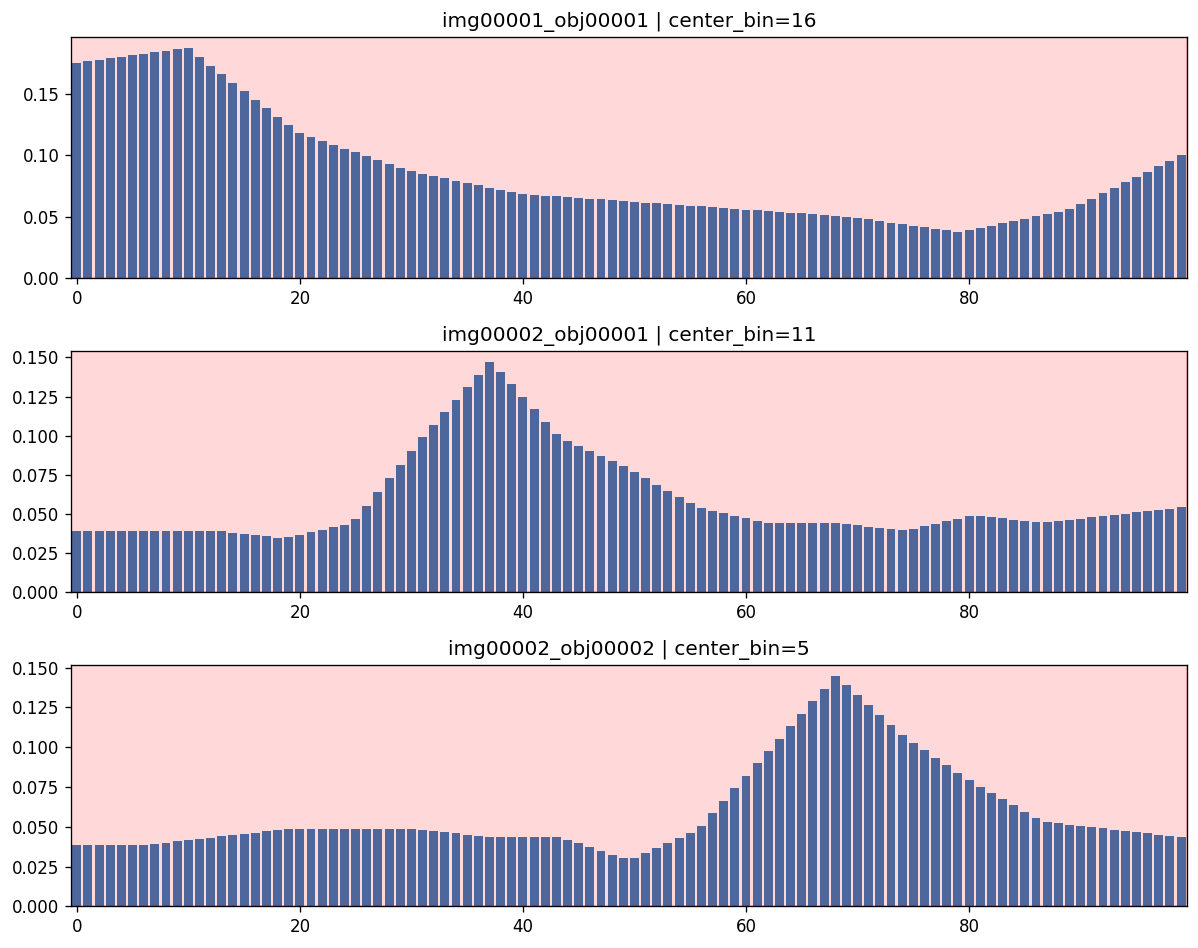

In [6]:

# =========================
# 6. Quick profile previews
# =========================
def plot_centered_profile(ax, centered_profile, spec, title=""):
    prof = np.asarray(centered_profile, dtype=float)
    x = np.arange(len(prof))
    ax.bar(x, prof, color="#2f78b7")

    t = np.asarray(spec["template"])
    active = np.where(t > 0)[0]
    if len(active) > 0:
        ax.axvspan(active.min() - 0.5, active.max() + 0.5, color="red", alpha=0.15)

    ax.set_title(title)
    ax.set_xlim(-0.5, len(prof) - 0.5)

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
for ax, idx in zip(axes, df.index[:3]):
    row = df.loc[idx]
    plot_centered_profile(
        ax,
        row["centered_profile"],
        FRAME_TEMPLATE_MAP["f10_entry_100"],
        title=f"{row['unique_key']} | center_bin={row['pt_center_bin_num']}"
    )
plt.tight_layout()
plt.show()

## 5. Build candidate table

In [7]:

# =========================
# 7. Candidate scoring
# =========================
rows = []
for row_idx, row in df.iterrows():
    prof = row["centered_profile"]
    for spec in FRAME_TEMPLATES:
        base_score = template_distance(prof, spec["frame_name"])
        mig_pen = migration_strength_penalty(spec["frame_name"], prof)
        score_strong = base_score + MIGRATION_WEIGHT * mig_pen

        rows.append({
            "row_idx": int(row_idx),
            "unique_key": row["unique_key"],
            "frame_idx": spec["frame_idx"],
            "frame_name": spec["frame_name"],
            "score": base_score,
            "migration_penalty": mig_pen,
            "score_strong": score_strong,
            "pseudotime_center_bin": row["pseudotime_center_bin"],
            "pt_center_bin_num": row["pt_center_bin_num"],
            "centered_profile": prof,
        })

candidates = pd.DataFrame(rows)
candidates["rank_within_frame"] = candidates.groupby("frame_name")["score"].rank(method="first", ascending=True)
candidates["rank_within_frame_strong"] = candidates.groupby("frame_name")["score_strong"].rank(method="first", ascending=True)

display(
    candidates.sort_values(["frame_idx", "score_strong"])
    [["frame_name", "unique_key", "score", "migration_penalty", "score_strong"]]
    .head(20)
)

,frame_name,unique_key,score,migration_penalty,score_strong
6480,f01_entry_10,img00325_obj00001,0.277103,2.319041,1.552576
1660,f01_entry_10,img00083_obj00001,0.273707,2.350599,1.566537
2040,f01_entry_10,img00103_obj00001,0.273357,2.365431,1.574344
960,f01_entry_10,img00045_obj00001,0.268587,2.375488,1.575105
7720,f01_entry_10,img00389_obj00001,0.268587,2.375488,1.575105
880,f01_entry_10,img00041_obj00001,0.276724,2.361972,1.575809
3280,f01_entry_10,img00167_obj00002,0.290730,2.337077,1.576122
0,f01_entry_10,img00001_obj00001,0.266588,2.381283,1.576293
2280,f01_entry_10,img00116_obj00001,0.274144,2.389948,1.588616
4980,f01_entry_10,img00251_obj00001,0.269779,2.401296,1.590492


## 6. Image preview builder

In [8]:

# =========================
# 8. Real-image preview builder
# =========================
def build_candidate_preview(row_idx, frame_name):
    row = df.loc[int(row_idx)]
    spec = FRAME_TEMPLATE_MAP[frame_name]

    dapi_raw = to_2d(read_image(row["path_dapi"]))
    dapi_fixed = scale_dapi_fixed(dapi_raw, out_hw=DAPI_CROP_HW)

    if "path_background" in row and pd.notna(row["path_background"]):
        bg_raw = to_2d(read_image(row["path_background"]))
    else:
        # blank background fallback
        bg_raw = np.zeros_like(dapi_raw, dtype=np.float32)

    bg_fixed = scale_dapi_fixed(bg_raw, out_hw=OVERLAY_CROP_HW)

    # dapi on same larger overlay size
    dapi_for_overlay = scale_dapi_fixed(dapi_raw, out_hw=OVERLAY_CROP_HW)
    overlay = make_overlay_fixed_dapi(bg_fixed, dapi_for_overlay)

    # stabilize both crops by centroid
    mask = make_binary_mask_from_dapi(dapi_for_overlay)
    cycx = mask_centroid(mask)
    if cycx is None:
        cy = overlay.shape[0] / 2
        cx = overlay.shape[1] / 2
    else:
        cy, cx = cycx

    overlay_crop = fixed_center_crop(
        overlay, cy, cx, OVERLAY_CROP_HW[0], OVERLAY_CROP_HW[1], fill_value=[1, 1, 1]
    )
    dapi_crop = fixed_center_crop(
        dapi_for_overlay, cy, cx, DAPI_CROP_HW[0], DAPI_CROP_HW[1], fill_value=0
    )

    return {
        "row": row,
        "spec": spec,
        "overlay_crop": overlay_crop,
        "dapi_crop": dapi_crop,
    }

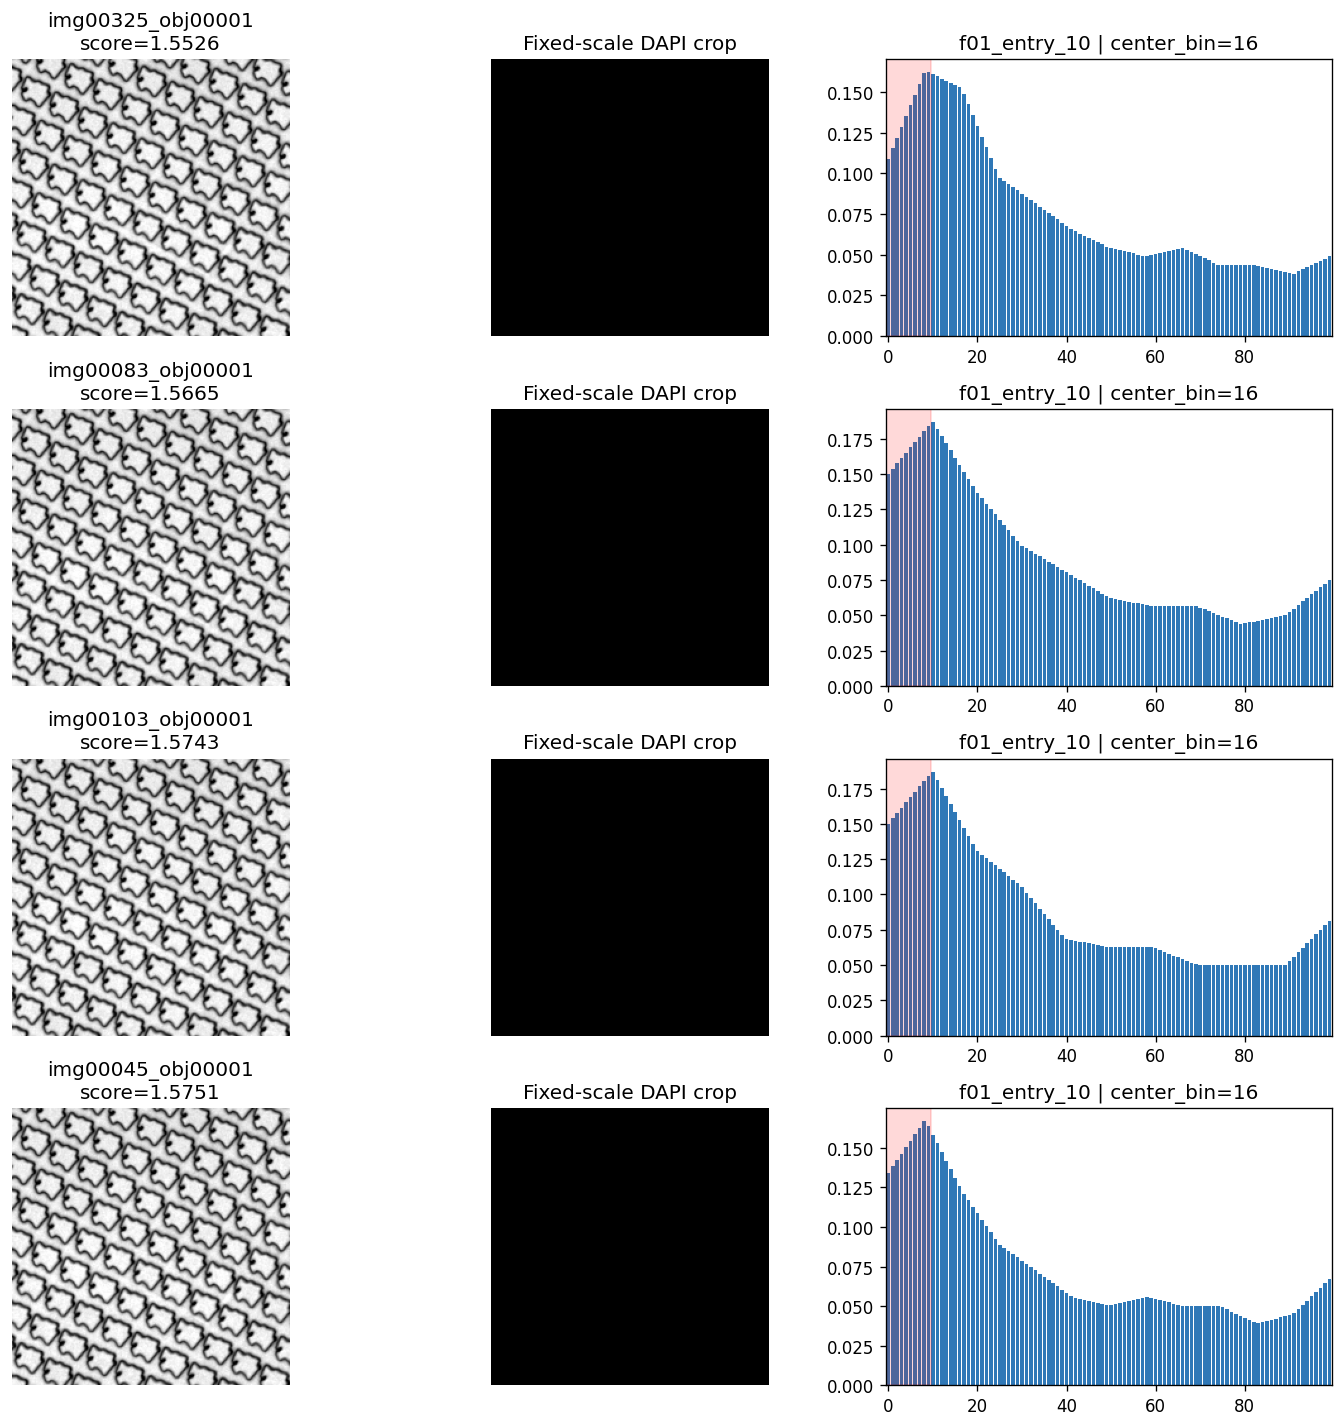

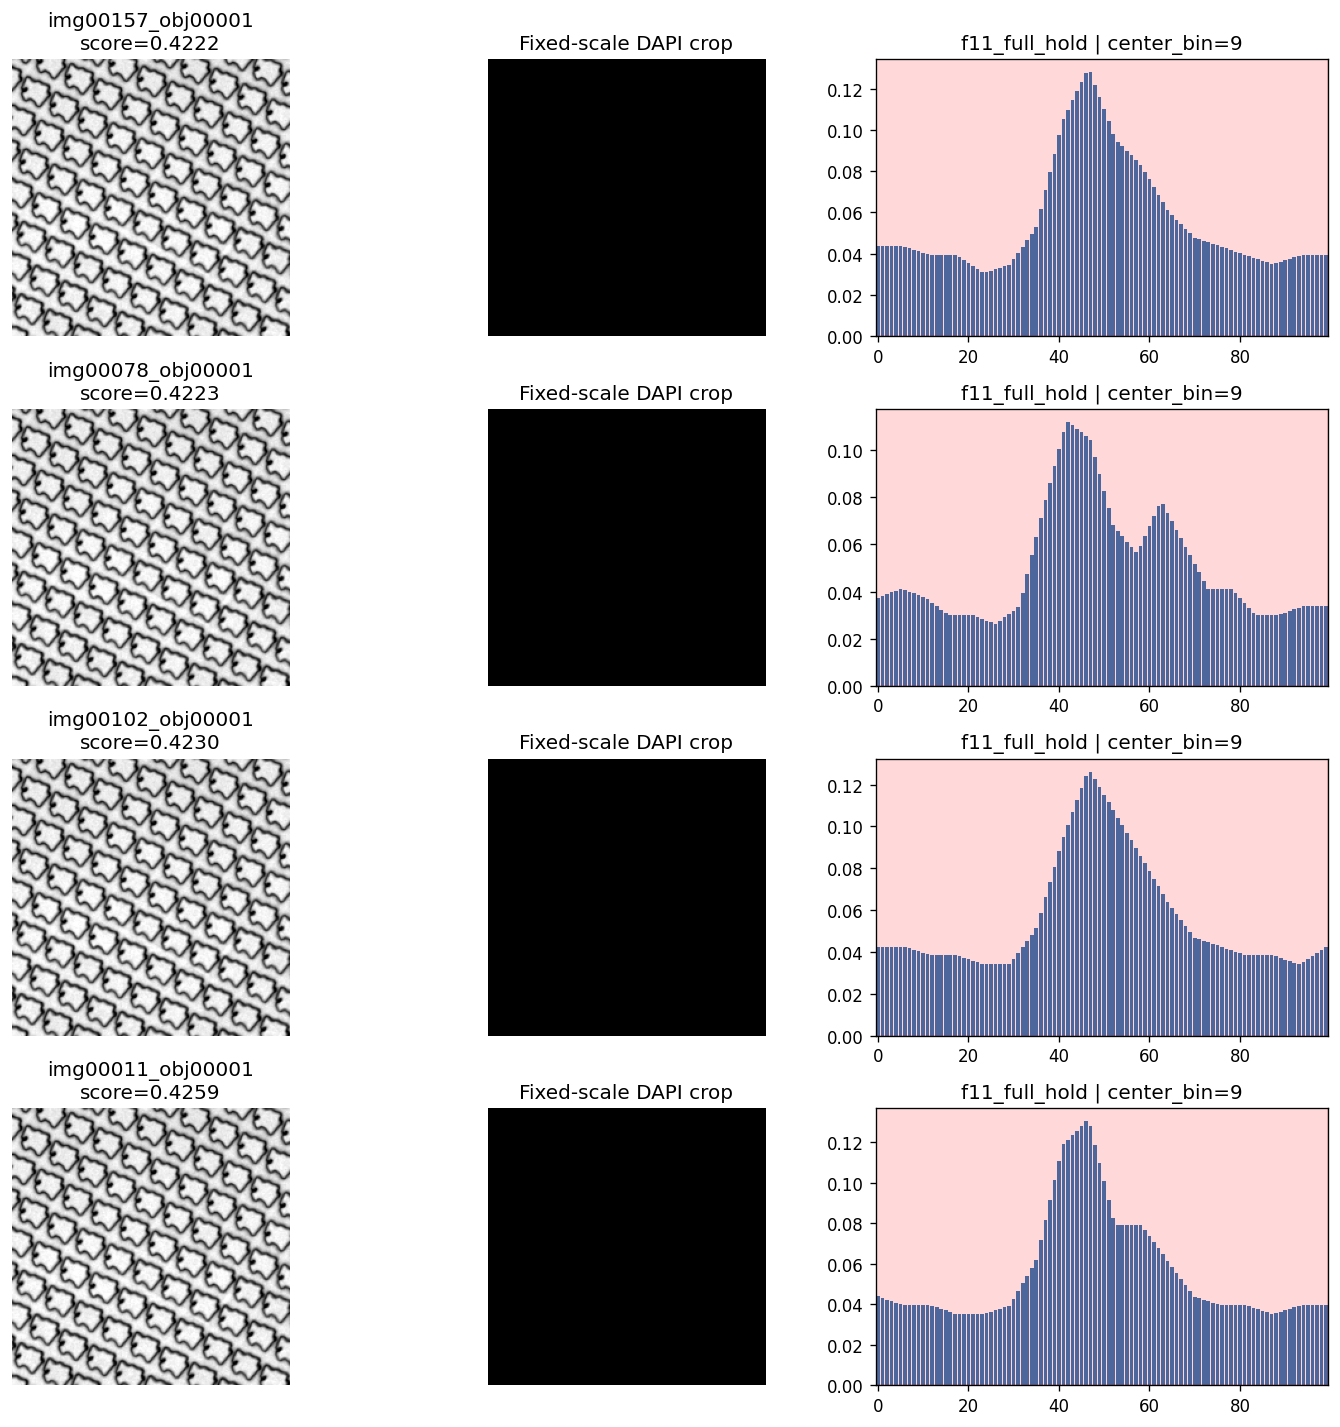

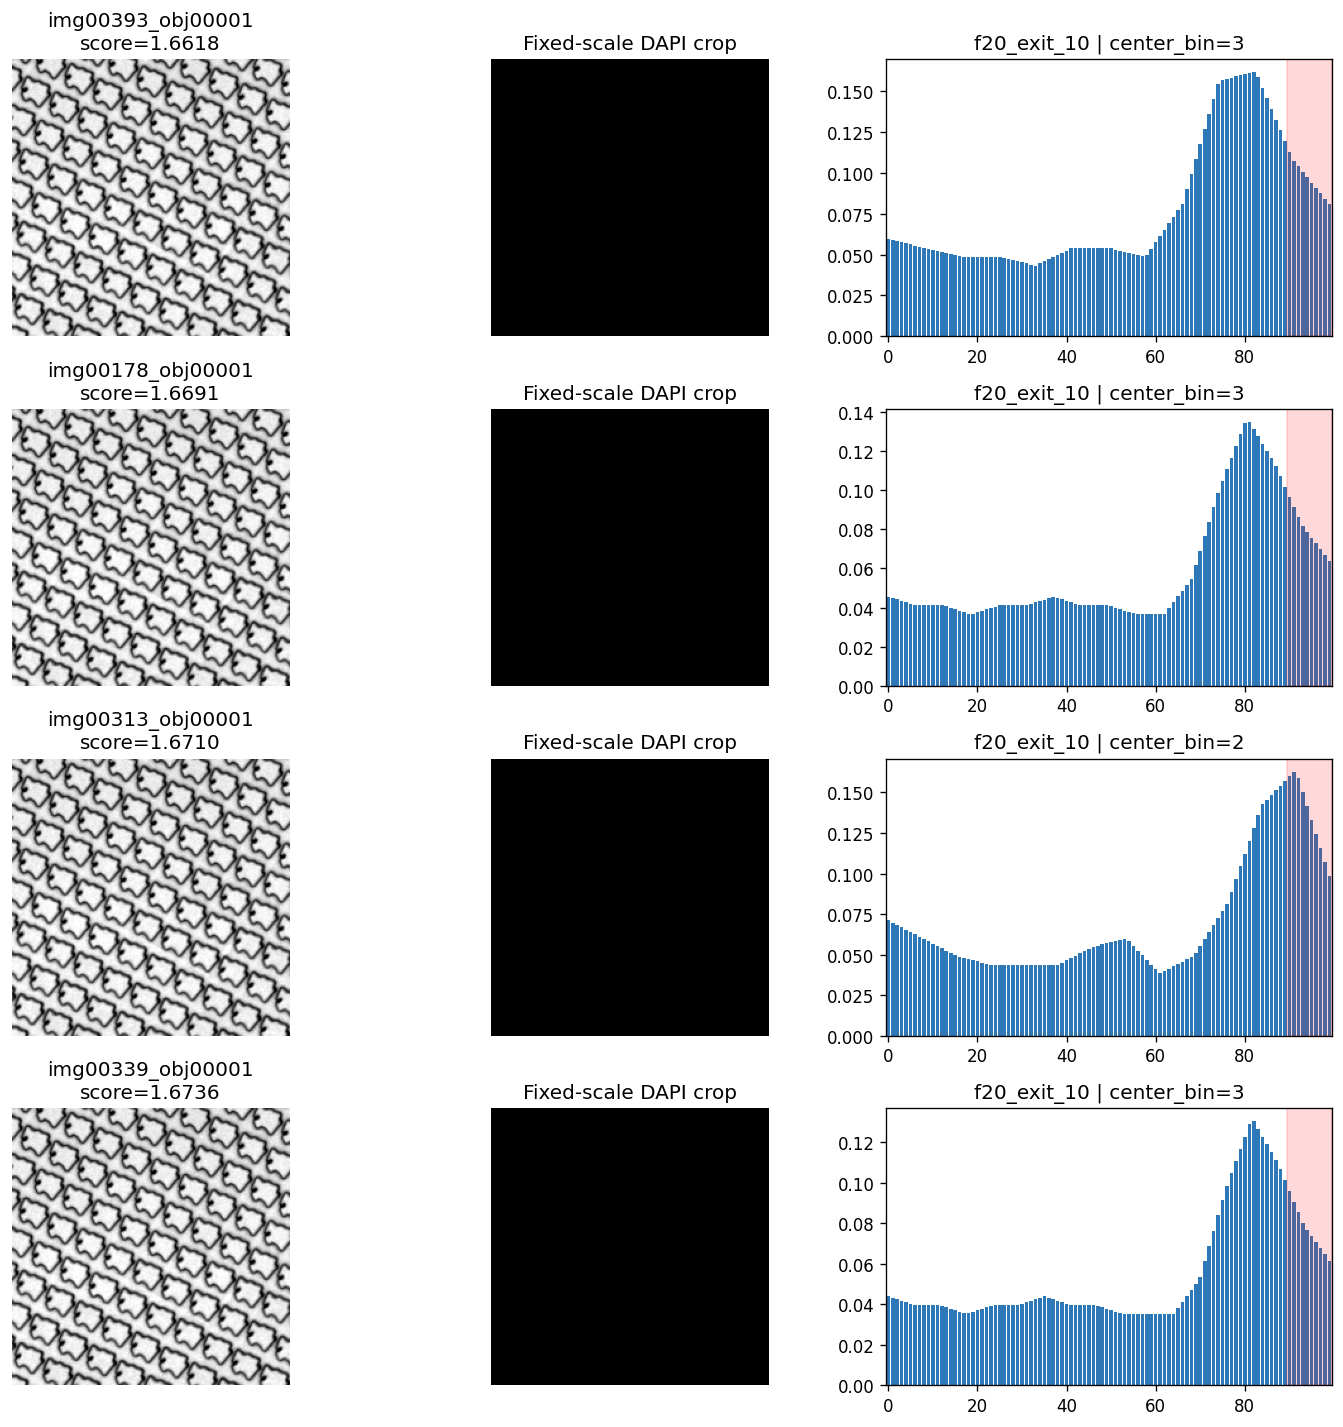

In [9]:

# =========================
# 9. Preview top candidates for one frame
# =========================
def preview_frame_candidates(frame_name, n=4):
    sub = (
        candidates.loc[candidates["frame_name"] == frame_name]
        .sort_values("score_strong", ascending=True)
        .head(n)
        .copy()
    )

    fig, axes = plt.subplots(len(sub), 3, figsize=(12, 3 * len(sub)))
    if len(sub) == 1:
        axes = np.expand_dims(axes, axis=0)

    for axrow, (_, cand) in zip(axes, sub.iterrows()):
        pack = build_candidate_preview(int(cand["row_idx"]), cand["frame_name"])
        spec = pack["spec"]

        axrow[0].imshow(pack["overlay_crop"])
        axrow[0].set_title(f"{cand['unique_key']}\nscore={cand['score_strong']:.4f}")
        axrow[0].axis("off")

        axrow[1].imshow(pack["dapi_crop"], cmap="gray")
        axrow[1].set_title("Fixed-scale DAPI crop")
        axrow[1].axis("off")

        plot_centered_profile(
            axrow[2],
            cand["centered_profile"],
            spec,
            title=f"{cand['frame_name']} | center_bin={cand['pt_center_bin_num']}"
        )

    plt.tight_layout()
    plt.show()

preview_frame_candidates("f01_entry_10", n=4)
preview_frame_candidates("f11_full_hold", n=4)
preview_frame_candidates("f20_exit_10", n=4)

## 7. Sequence selection

In [ ]:

# =========================
# 10. Sequence selection
# =========================
def estimate_pack_features(pack):
    mask = make_binary_mask_from_dapi(pack["dapi_crop"])
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return {"cx": np.nan, "cy": np.nan, "area": 0.0, "w": 0.0, "h": 0.0}

    cx = float(xs.mean())
    cy = float(ys.mean())
    area = float(mask.sum())
    w = float(xs.max() - xs.min() + 1)
    h = float(ys.max() - ys.min() + 1)

    return {"cx": cx, "cy": cy, "area": area, "w": w, "h": h}


def smooth_cost(prev_feat, curr_feat):
    if prev_feat is None:
        return 0.0

    cx_cost = abs(curr_feat["cx"] - prev_feat["cx"])
    cy_cost = abs(curr_feat["cy"] - prev_feat["cy"])
    area_cost = abs(curr_feat["area"] - prev_feat["area"]) / max(1.0, prev_feat["area"])
    w_cost = abs(curr_feat["w"] - prev_feat["w"]) / max(1.0, prev_feat["w"])
    h_cost = abs(curr_feat["h"] - prev_feat["h"]) / max(1.0, prev_feat["h"])

    return 0.8 * cx_cost + 0.8 * cy_cost + 20.0 * area_cost + 8.0 * w_cost + 8.0 * h_cost


def select_unique_greedy_sequence(candidates_df, frame_order):
    selected_rows = []
    used_keys = set()

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score_strong", "rank_within_frame_strong"], ascending=[True, True])
            .copy()
        )

        chosen = None
        for _, r in sub.iterrows():
            if r["unique_key"] not in used_keys:
                chosen = r
                break

        if chosen is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    return pd.DataFrame(selected_rows).reset_index(drop=True)


def select_unique_greedy_smooth_sequence(candidates_df, frame_order, top_k_per_frame=TOP_K_PER_FRAME):
    selected_rows = []
    used_keys = set()
    prev_feat = None

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(["score_strong", "rank_within_frame_strong"], ascending=[True, True])
            .head(top_k_per_frame)
            .copy()
        )

        best_row = None
        best_total = np.inf
        best_feat = None

        for _, r in sub.iterrows():
            if r["unique_key"] in used_keys:
                continue

            pack = build_candidate_preview(int(r["row_idx"]), r["frame_name"])
            feat = estimate_pack_features(pack)
            continuity = smooth_cost(prev_feat, feat)

            total = float(r["score_strong"]) + 0.015 * continuity
            if total < best_total:
                best_total = total
                best_row = r
                best_feat = feat

        if best_row is None:
            print(f"WARNING: no unused candidate found for {frame_name}")
            continue

        selected_rows.append(best_row)
        used_keys.add(best_row["unique_key"])
        prev_feat = best_feat

    return pd.DataFrame(selected_rows).reset_index(drop=True)


if SEQUENCE_MODE == "greedy_smooth":
    sequence_auto = select_unique_greedy_smooth_sequence(candidates, FRAME_ORDER)
else:
    sequence_auto = select_unique_greedy_sequence(candidates, FRAME_ORDER)

sequence_auto = sequence_auto.sort_values("frame_idx").reset_index(drop=True)
display(sequence_auto[["frame_idx", "frame_name", "unique_key", "score_strong"]])

## 8. GIF rendering

In [ ]:

# =========================
# 11. GIF frame renderer
# =========================
GIF_DIR = OUT_DIR / "gif_build_stabilized"
GIF_DIR.mkdir(parents=True, exist_ok=True)

def render_sequence_frame(row, out_path=None):
    pack = build_candidate_preview(int(row["row_idx"]), row["frame_name"])
    spec = pack["spec"]
    meta_row = pack["row"]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

    axes[0].imshow(pack["overlay_crop"])
    axes[0].set_title(
        f"{row['frame_name']}\n{meta_row['unique_key']}\nscore={row['score_strong']:.4f}"
    )
    axes[0].axis("off")

    axes[1].imshow(pack["dapi_crop"], cmap="gray")
    axes[1].set_title("Fixed-scale DAPI crop")
    axes[1].axis("off")

    plot_centered_profile(
        axes[2],
        meta_row["centered_profile"],
        spec,
        title=f"center_bin={meta_row['pt_center_bin_num']}"
    )

    plt.tight_layout()

    tmp_path = GIF_DIR / "_tmp_frame.png"
    fig.savefig(tmp_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    arr = imageio.imread(tmp_path)
    arr = pad_to_canvas(arr, GIF_FRAME_SIZE[0], GIF_FRAME_SIZE[1], bg_value=255)

    if out_path is not None:
        imageio.imwrite(out_path, arr)

    return arr


gif_frames = []
for _, row in sequence_auto.iterrows():
    out_png = GIF_DIR / f"{int(row['frame_idx']):02d}_{row['frame_name']}.png"
    frame_arr = render_sequence_frame(row, out_path=out_png)
    gif_frames.append(frame_arr)

    if str(row["frame_name"]) in {"f10_entry_100", "f11_full_hold"}:
        for _ in range(GIF_HOLD_MIDDLE_N):
            gif_frames.append(frame_arr)

for _ in range(GIF_HOLD_LAST_N):
    gif_frames.append(gif_frames[-1])

gif_path = GIF_DIR / "animation_auto_stabilized.gif"
imageio.mimsave(gif_path, gif_frames, duration=GIF_FRAME_DURATION, loop=0)

print("Saved:", gif_path)
gif_path

In [ ]:

# =========================
# 12. Show the main GIF
# =========================
from IPython.display import Image as IPyImage, display

display(IPyImage(filename=str(gif_path)))

## 9. Side quest: generate 10 unique randomized animations

This samples one candidate per frame from the top candidate pool for that frame.

In [ ]:

# =========================
# 13. Ten randomized GIFs
# =========================
def sample_random_sequence(candidates_df, frame_order, score_col="score_strong", top_k=12, seed=None):
    rng = random.Random(seed)
    used_keys = set()
    rows = []

    for frame_name in frame_order:
        sub = (
            candidates_df.loc[candidates_df["frame_name"] == frame_name]
            .sort_values(score_col, ascending=True)
            .head(top_k)
            .copy()
        )

        sub = sub.loc[~sub["unique_key"].isin(used_keys)].copy()
        if len(sub) == 0:
            return None

        chosen = sub.sample(n=1, random_state=rng.randint(0, 10_000_000)).iloc[0]
        rows.append(chosen)
        used_keys.add(chosen["unique_key"])

    return pd.DataFrame(rows).reset_index(drop=True)


RANDOM_GIF_DIR = OUT_DIR / "random_gifs"
RANDOM_GIF_DIR.mkdir(parents=True, exist_ok=True)

def build_gif_from_sequence(seq_df, gif_name):
    gif_frames = []

    for _, row in seq_df.sort_values("frame_idx").iterrows():
        out_png = RANDOM_GIF_DIR / f"tmp_{gif_name}_{row['frame_name']}.png"
        frame_arr = render_sequence_frame(row, out_path=out_png)
        gif_frames.append(frame_arr)

    for _ in range(GIF_HOLD_LAST_N):
        gif_frames.append(gif_frames[-1])

    gif_path = RANDOM_GIF_DIR / gif_name
    imageio.mimsave(gif_path, gif_frames, duration=GIF_FRAME_DURATION, loop=0)
    return gif_path


random_sequences = []
for i in range(10):
    seq = sample_random_sequence(
        candidates,
        FRAME_ORDER,
        score_col="score_strong",
        top_k=12,
        seed=100 + i
    )
    if seq is not None:
        random_sequences.append(seq)

gif_paths = []
for i, seq in enumerate(random_sequences, start=1):
    p = build_gif_from_sequence(seq, f"animation_random_{i:02d}.gif")
    gif_paths.append(p)

print("Random GIFs created:", len(gif_paths))
gif_paths[:5]

In [ ]:

# =========================
# 14. Display one random GIF example
# =========================
if len(gif_paths) > 0:
    display(IPyImage(filename=str(gif_paths[0])))
else:
    print("No random GIFs were created.")